# 総括編: 定性トピックとケーススタディ（Hull 11e Ch.1, 8, 16, 35, 36, 37）

`johnhull/volumes` シリーズ**最終巻**。残りの定性・事例章をまとめます：

- **Ch.1 イントロダクション** — デリバティブの全体像
- **Ch.8 証券化と金融危機** — ABS / CDO / 2007–08
- **Ch.16 従業員ストックオプション（ESO）** — ベスティング・希薄化・費用計上
- **Ch.35 エネルギー・コモディティ** — 平均回帰・利便利回り・天候デリバ
- **Ch.36 リアルオプション** — 経営の柔軟性をオプションとして評価
- **Ch.37 デリバティブの失敗事例** — ローグトレーダー・モデル/流動性リスク

> この巻の完成で **Hull 11e 全37章カバー達成**。共通関数は既存の `hullkit` を再利用

In [1]:
%matplotlib widget

In [2]:
# --- imports & 共通設定 ---
import math

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

from hullkit import bsm, nbplot, trees

plt = nbplot.setup()  # japanize_matplotlib + plt.ioff()

## 1. デリバティブの全体像（Ch.1）

**デリバティブ** = 他の資産（原資産）の価格に価値が依存する金融商品。

| 軸 | 分類 |
|---|---|
| 市場 | 取引所（標準化・CCP）／ OTC（相対・柔軟） |
| 参加者 | ヘッジャー（リスク削減）／ 投機家（リスクテイク）／ 裁定者（無リスク利益） |
| 商品 | フォワード・先物 ／ オプション ／ スワップ |

本シリーズはこの全商品を一巡しました（フォワード/先物→第4冊、オプション→第2-3冊、
スワップ→第7冊、金利→第4・11冊、信用→第9冊、エキゾチック→第10冊）。

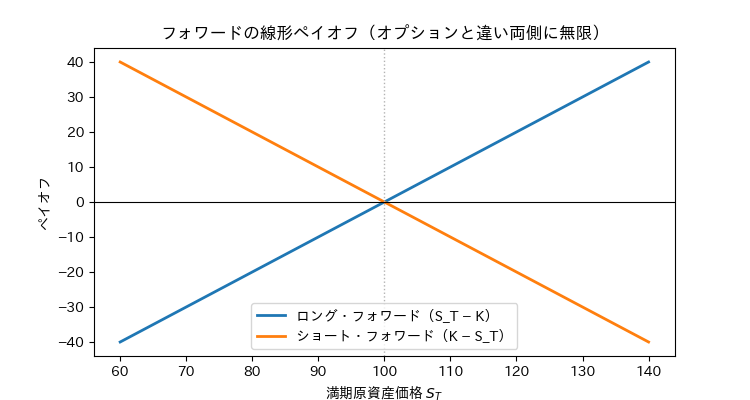

In [3]:
# --- ロング/ショート・フォワードのペイオフ ---
K_f = 100.0
s_t = np.linspace(60.0, 140.0, 200)
fig1, ax1 = plt.subplots(figsize=(7.5, 4))
fig1.canvas.header_visible = False
ax1.plot(s_t, s_t - K_f, lw=2, label="ロング・フォワード（S_T − K）")
ax1.plot(s_t, K_f - s_t, lw=2, label="ショート・フォワード（K − S_T）")
ax1.axhline(0.0, color="black", lw=0.8)
ax1.axvline(K_f, color="0.7", ls=":", lw=1)
ax1.set_xlabel("満期原資産価格 $S_T$")
ax1.set_ylabel("ペイオフ")
ax1.set_title("フォワードの線形ペイオフ（オプションと違い両側に無限）")
ax1.legend()
display(fig1.canvas)

## 2. 証券化と金融危機（Ch.8）

- **ABS（資産担保証券）**: 住宅ローン等のプールを**トランシェ**（エクイティ→メザニン→シニア）に分割
- **ABS CDO**: ABS のメザニンを再度プールして再トランシェ化（リスクの「再パッケージ」）
- **オリジネート・トゥ・ディストリビュート**: 組成者が信用リスクを保持しない → 審査の甘さ（エージェンシー問題）
- 2007–08: 住宅価格下落 → サブプライム損失 → AAA とされた上位トランシェまで毀損 → 連鎖

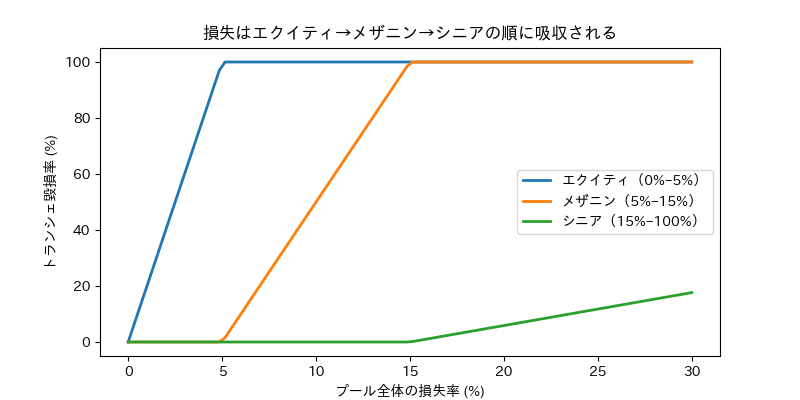

プール損失 12% のとき:
  エクイティ: 損失額 5.0%（トランシェ毀損率 100%）
  メザニン: 損失額 7.0%（トランシェ毀損率 70%）
  シニア: 損失額 0.0%（トランシェ毀損率 0%）


In [4]:
# --- トランシェの損失ウォーターフォール（プール損失をエクイティから順に吸収） ---
tranches = [("エクイティ", 0.0, 0.05), ("メザニン", 0.05, 0.15), ("シニア", 0.15, 1.0)]


def allocate_loss(pool_loss, lo, hi):
    return min(max(pool_loss - lo, 0.0), hi - lo)


fig2, ax2 = plt.subplots(figsize=(8, 4))
fig2.canvas.header_visible = False
pool_losses = np.linspace(0.0, 0.30, 100)
for name, lo, hi in tranches:
    alloc = [allocate_loss(pl, lo, hi) / (hi - lo) for pl in pool_losses]
    ax2.plot(pool_losses * 100, np.array(alloc) * 100, lw=2, label=f"{name}（{lo:.0%}–{hi:.0%}）")
ax2.set_xlabel("プール全体の損失率 (%)")
ax2.set_ylabel("トランシェ毀損率 (%)")
ax2.set_title("損失はエクイティ→メザニン→シニアの順に吸収される")
ax2.legend()
display(fig2.canvas)

pl = 0.12
print(f"プール損失 {pl:.0%} のとき:")
for name, lo, hi in tranches:
    a = allocate_loss(pl, lo, hi)
    print(f"  {name}: 損失額 {a:.1%}（トランシェ毀損率 {a / (hi - lo):.0%}）")

### 危機の教訓（Ch.8）

- **相関の過小評価**: トランシェ評価のコピュラ（第9冊）はテール相関を過小に見積もり、
  「分散したはずの」リスクが同時に顕在化した
- **格付けへの過信**: AAA = 安全ではない。モデルとデータの前提が崩れると上位も毀損
- **インセンティブの歪み**: 組成・販売・格付けの各段で短期利益が優先された

### ABS CDO — リスクの再パッケージ

ABS のメザニン（BBB 相当）を集めて再びトランシェ化すると、
**ABS CDO の上位**が AAA を名乗る。だが原資産は同じサブプライムの相関リスクで、
住宅市場という単一ファクターに同時に晒されている。
「分散」は見かけだけで、システミックショックには無力だった（Ch.8 / 第9冊コピュラ参照）。

## 3. 従業員ストックオプション（ESO, Ch.16）

- 報酬として付与されるコール。**ベスティング期間**（権利確定まで行使不可）・
  **早期行使**（流動性・分散動機）・**没収**（離職）が特徴
- FAS123R 以降、**費用計上**が必須に。公正価値の見積りが論点
- 評価の実務: 満期そのものでなく**期待存続期間**を使った BSM が一般的
- 新株発行による**希薄化**を価値に織り込む（$N/(N+M)$ 調整）

In [5]:
# --- ESO 評価: 期待存続期間 + 希薄化調整 ---
S_E, K_E, R_E, SIG_E = 100.0, 100.0, 0.05, 0.30
T_contract, T_expected = 10.0, 6.0  # 契約満期 vs 期待存続期間
# 期待存続期間で BSM 評価（早期行使を反映した実務近似）
v_contract = bsm.call_price(S_E, K_E, R_E, SIG_E, T_contract)
v_expected = bsm.call_price(S_E, K_E, R_E, SIG_E, T_expected)
print(f"契約満期10年で評価   = {v_contract:.4f}")
print(f"期待存続6年で評価     = {v_expected:.4f}（早期行使を反映してこちらが実務的）")

# 希薄化: 既存株 N、新規発行 M（オプション）
N_shares, M_options = 10_000_000, 1_000_000
dilution = N_shares / (N_shares + M_options)
v_diluted = v_expected * dilution
print(f"\n希薄化係数 N/(N+M) = {dilution:.4f}")
print(f"希薄化後の1オプション価値 = {v_diluted:.4f}")

契約満期10年で評価   = 52.5668
期待存続6年で評価     = 39.8557（早期行使を反映してこちらが実務的）

希薄化係数 N/(N+M) = 0.9091
希薄化後の1オプション価値 = 36.2325


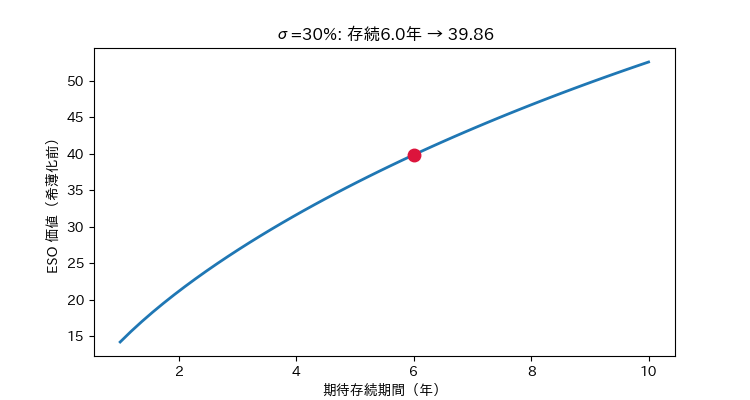

In [6]:
# --- 期待存続期間と ESO 価値（インタラクティブ） ---
fig3, ax3 = plt.subplots(figsize=(7.5, 4))
fig3.canvas.header_visible = False
life_sl = widgets.FloatSlider(value=6.0, min=1.0, max=10.0, step=0.5, description="期待存続(年)")
vol_sl = widgets.FloatSlider(value=0.30, min=0.15, max=0.60, step=0.05, description="σ")


def _upd_eso(change=None):
    ax3.clear()
    lives = np.linspace(1.0, 10.0, 50)
    vals = [bsm.call_price(S_E, K_E, R_E, vol_sl.value, t) for t in lives]
    ax3.plot(lives, vals, lw=2)
    v_now = bsm.call_price(S_E, K_E, R_E, vol_sl.value, life_sl.value)
    ax3.plot(life_sl.value, v_now, "o", ms=9, color="crimson")
    ax3.set_xlabel("期待存続期間（年）")
    ax3.set_ylabel("ESO 価値（希薄化前）")
    ax3.set_title(f"σ={vol_sl.value:.0%}: 存続{life_sl.value:.1f}年 → {v_now:.2f}")
    fig3.canvas.draw_idle()


life_sl.observe(_upd_eso, "value")
vol_sl.observe(_upd_eso, "value")
_upd_eso()
display(widgets.HBox([life_sl, vol_sl]), fig3.canvas)